# Manual Segmentation for Comparative Analysis for NHANES I dataset Random Forest Model

This notebook implements manual segmentation based on predictor variables (agents) using the same sum-based aggregation strategy.

**Approach:** Manually segment the cohort based on specific predictor variable criteria (age > 50 AND sex_isFemale == false), then apply the same aggregation method to both segments:
- **Subgroup S₁** (males over 50): Sum-based aggregation as in risk stratification
- **Subgroup S₂** (rest of cohort): Sum-based aggregation as in risk stratification

This demonstrates how the same aggregation method reveals different patterns when applied to different population subgroups defined by hypothesis-driven criteria.

In [1]:
import os
import sys
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cgt_perezsechi.visualization.graph import draw
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

c:\Workspace\IJAR\IJAR-python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Configure matplotlib for VS Code Jupyter
%matplotlib inline
# Set pandas display options to avoid truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_info_columns', 99999)

In [3]:
# Load data
X = pd.read_pickle("../../../../data/nhanesi/x_values.pkl")
num_patients = 500
X_shapley = X.iloc[:num_patients, :]
shap_values = np.load("../../../../data/nhanesi/rf/shap_values.npy")
shap_interaction_values = np.load("../../../../data/nhanesi/rf/shap_interaction_values.npy")

print(f"Loaded data: {num_patients} patients, {X_shapley.shape[1]} features")
print(f"SHAP values shape: {shap_values.shape}")
print(f"SHAP interaction values shape: {shap_interaction_values.shape}")

Loaded data: 500 patients, 79 features
SHAP values shape: (500, 79)
SHAP interaction values shape: (500, 79, 79)


## Manual Segmentation Based on Predictor Variables

We create a manual filter based on specific predictor variable criteria:
- **Subgroup of interest**: Males over 50 years old (age > 50 AND sex_isFemale == false)
- **Rest of cohort**: All other individuals

In [4]:
# Create manual segmentation mask
# Subgroup: age > 50 AND sex_isFemale == false (males over 50)
age_over_50 = X_shapley['age'] > 50
is_male = X_shapley['sex_isFemale'] == False

subgroup_mask = age_over_50 & is_male
rest_mask = ~subgroup_mask

# Display segmentation statistics
print("\n=== Manual Segmentation Statistics ===")
print(f"\nSubgroup (males over 50):")
print(f"  N = {subgroup_mask.sum()} patients ({subgroup_mask.sum()/num_patients*100:.1f}%)")
print(f"  Age range: [{X_shapley[subgroup_mask]['age'].min():.0f}, {X_shapley[subgroup_mask]['age'].max():.0f}]")
print(f"  Age mean: {X_shapley[subgroup_mask]['age'].mean():.1f}")

print(f"\nRest of cohort:")
print(f"  N = {rest_mask.sum()} patients ({rest_mask.sum()/num_patients*100:.1f}%)")
print(f"  Age range: [{X_shapley[rest_mask]['age'].min():.0f}, {X_shapley[rest_mask]['age'].max():.0f}]")
print(f"  Age mean: {X_shapley[rest_mask]['age'].mean():.1f}")
print(f"  Females: {X_shapley[rest_mask]['sex_isFemale'].sum()} ({X_shapley[rest_mask]['sex_isFemale'].sum()/rest_mask.sum()*100:.1f}%)")


=== Manual Segmentation Statistics ===

Subgroup (males over 50):
  N = 111 patients (22.2%)
  Age range: [51, 74]
  Age mean: 63.8

Rest of cohort:
  N = 389 patients (77.8%)
  Age range: [25, 74]
  Age mean: 44.9
  Females: 295 (75.8%)


## Build Networks with Sum-Based Aggregation

We apply the same sum-based aggregation strategy to both segments, as defined in equations eq:manual_s1_node and eq:manual_s2_node:

For each segment, we compute:
- **Node weights**: N*ᵢ = Σₜ∈S Shᵢ(Δᵗ) / Σᵤ Σₜ∈S |Shᵤ(Δᵗ)|
- **Edge weights**: E*ᵢⱼ = Σₜ∈S Iᵢⱼ(Δᵗ) / Σᵥ Σᵤ>ᵥ Σₜ∈S |Iᵤᵥ(Δᵗ)|

where S is the set of patients in the segment (S₁ for males over 50, S₂ for the rest).

In [5]:
def build_network_sum_based(patient_mask, shap_values, shap_interaction_values, X_shapley):
    """
    Build psi and r matrices for a specific patient segment using sum-based aggregation.
    
    This follows the same approach as risk stratification:
    - Node weights: N*ᵢ = Σₜ∈S Shᵢ(Δᵗ) / Σᵤ Σₜ∈S |Shᵤ(Δᵗ)|
    - Edge weights: E*ᵢⱼ = Σₜ∈S Iᵢⱼ(Δᵗ) / Σᵥ Σᵤ>ᵥ Σₜ∈S |Iᵤᵥ(Δᵗ)|
    
    Parameters:
    -----------
    patient_mask : boolean array
        Mask for selecting patients in this segment
    shap_values : numpy array
        SHAP values array (all patients)
    shap_interaction_values : numpy array
        SHAP interaction values array (all patients)
    X_shapley : DataFrame
        Feature dataframe
    
    Returns:
    --------
    psi_1, r_1, psi_2, r_2 : DataFrames
        Non-normalized and normalized node/edge weights
    """
    # Filter SHAP values for this segment
    segment_shap = shap_values[patient_mask]
    segment_interaction = shap_interaction_values[patient_mask]
    
    # Calculate psi_1 (node weights)
    # Numerator: sum over patients for each feature
    # Denominator: sum of absolute values over all patients and all features
    sum_shap = np.sum(np.abs(segment_shap), axis=(0, 1))
    psi_1 = pd.DataFrame()
    psi_1['value'] = np.sum(segment_shap, axis=0) / sum_shap
    psi_1.set_index(X_shapley.columns, inplace=True)
    
    # Calculate r_1 (edge weights) - use only lower triangular matrix for denominator
    n_patients_segment = segment_interaction.shape[0]
    n_variables = segment_interaction.shape[1]
    
    # Clean NaN values
    filtered_interaction = np.nan_to_num(segment_interaction.copy())
    
    # Create lower triangular mask (u > v means row > col, excluding diagonal)
    lower_tri_mask = np.tril(np.ones((n_variables, n_variables), dtype=bool), k=-1)
    
    # Calculate denominator: sum of absolute values of lower triangular elements only
    # sum_v sum_{u>v} sum_t |I_uv(Delta^t)|
    sum_interaction_lower = 0.0
    for patient_idx in range(n_patients_segment):
        sum_interaction_lower += np.sum(np.abs(filtered_interaction[patient_idx][lower_tri_mask]))
    
    # Calculate numerator: sum over patients for each (i,j) pair
    # sum_t I_ij(Delta^t)
    cumulative_interaction = np.sum(filtered_interaction, axis=0)
    
    # Zero out diagonal (remove self-interactions)
    np.fill_diagonal(cumulative_interaction, 0)
    
    # Calculate edge weights: E*_ij = numerator / denominator
    r_1 = pd.DataFrame(cumulative_interaction / sum_interaction_lower)
    r_1.rename(columns=dict(list(zip(r_1.columns, X_shapley.columns))), inplace=True)
    r_1.set_index(X_shapley.columns, inplace=True)
    
    # Normalize for visualization
    psi_2 = normalize_psi(psi_1)
    r_2 = normalize_r(r_1)
    
    return psi_1, r_1, psi_2, r_2

In [6]:
from IPython.display import display, Math

# Clean SHAP values (handle NaN)
shap_values_clean = np.nan_to_num(shap_values)

# Build network for subgroup S₁ (males over 50)
print("Building network for subgroup S₁ (males over 50)...")
subgroup_psi_1, subgroup_r_1, subgroup_psi_2, subgroup_r_2 = build_network_sum_based(
    subgroup_mask, shap_values_clean, shap_interaction_values, X_shapley
)
print("  Done.")

display(Math(r"\mathcal{N}^*_i = \frac{\sum_{t \in S_1} Sh_{i}(\Delta^{t})}{\sum_{u=1}^{n} \sum_{t \in S_1} |Sh_{u}(\Delta^{t})|}"))
display(subgroup_psi_2)
display(Math(r"\mathcal{E}^*_{ij} = \frac{\sum_{t \in S_1} I_{ij}(\Delta^{t})}{\sum_{v=1}^{n} \sum_{u > v}^{n} \sum_{t \in S_1} |I_{uv}(\Delta^{t})|}"))
display(subgroup_r_2)

# Build network for rest of cohort S₂
print("\nBuilding network for rest of cohort S₂...")
rest_psi_1, rest_r_1, rest_psi_2, rest_r_2 = build_network_sum_based(
    rest_mask, shap_values_clean, shap_interaction_values, X_shapley
)
print("  Done.")

display(Math(r"\mathcal{N}^*_i = \frac{\sum_{t \in S_2} Sh_{i}(\Delta^{t})}{\sum_{u=1}^{n} \sum_{t \in S_2} |Sh_{u}(\Delta^{t})|}"))
display(rest_psi_2)
display(Math(r"\mathcal{E}^*_{ij} = \frac{\sum_{t \in S_2} I_{ij}(\Delta^{t})}{\sum_{v=1}^{n} \sum_{u > v}^{n} \sum_{t \in S_2} |I_{uv}(\Delta^{t})|}"))
display(rest_r_2)

Building network for subgroup S₁ (males over 50)...
  Done.


<IPython.core.display.Math object>

,value
sex_isFemale,1.612135e-01
age,1.000000e+00
physical_activity,-4.804628e-04
serum_albumin,3.524324e-03
alkaline_phosphatase,-2.817485e-03
alkaline_phosphatase_isUnacceptable,5.413948e-05
alkaline_phosphatase_isTestnotdone,2.627854e-06
SGOT,6.609286e-03
SGOT_isUnacceptable,7.120142e-04
SGOT_isTestnotdone,-4.287860e-06


<IPython.core.display.Math object>

,sex_isFemale,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,BUN,BUN_isUnacceptable,BUN_isTestnotdone,calcium,calcium_isUnacceptable,calcium_isTestnotdone,creatinine,creatinine_isUnacceptable,creatinine_isTestnotdone,potassium,potassium_isUnacceptable,sodium,sodium_isUnacceptable,total_bilirubin,total_bilirubin_isUnacceptable,total_bilirubin_isTestnotdone,serum_protein,red_blood_cells,red_blood_cells_isUnacceptable,red_blood_cells_isBlankbutapplicable,white_blood_cells,white_blood_cells_isUnacceptable,white_blood_cells_isBlankbutapplicable,hemoglobin,hemoglobin_isMissing,hematocrit,hematocrit_isUnacceptable,hematocrit_isMissing,platelets_isNormal,platelets_isIncreased,platelets_isDecreased,platelets_isNoestimate,segmented_neutrophils,lymphocytes,monocytes,eosinophils,basophils,band_neutrophils,cholesterol,cholesterol_isMissing,urine_albumin_isNegative,urine_albumin_is>=30,urine_albumin_is>=100,urine_albumin_is>=300,urine_albumin_is>=1000,urine_albumin_isTrace,urine_albumin_isBlankbutapplicable,urine_glucose_isNegative,urine_glucose_isLight,urine_glucose_isMedium,urine_glucose_isDark,urine_glucose_isVerydark,urine_glucose_isTrace,urine_glucose_isBlankbutapplicable,urine_pH,urine_pH_isBlankbutapplicable,urine_hematest_isNegative,urine_hematest_isSmall,urine_hematest_isModerate,urine_hematest_isLarge,urine_hematest_isBlankbutapplicable,sedimentation_rate,sedimentation_rate_isBlankbutapplicable,uric_acid,uric_acid_isUnacceptable,uric_acid_isTestnotdone,systolic_blood_pressure,pulse_pressure,bmi
sex_isFemale,0.000000e+00,1.000000,9.133865e-03,6.902928e-03,3.871318e-02,0.000000,-0.000036,4.870535e-04,-1.308119e-02,0.000000,3.674697e-03,2.112170e-04,0.0,2.743009e-03,0.000137,-3.707817e-05,1.813245e-03,-6.701100e-04,0.0,-1.369484e-04,1.112563e-04,1.319746e-05,0.000000e+00,0.028945,-0.000082,8.907588e-05,-1.040637e-02,-5.389621e-03,-0.000637,0.000493,4.742788e-03,-1.057036e-04,7.297818e-04,-8.762470e-02,0.0,-6.197152e-02,0.000007,0.0,-3.935747e-07,-0.000029,0.000000,0.0,-2.569248e-03,1.007837e-03,0.001096,-0.001249,5.510505e-05,9.593405e-04,-2.211854e-02,0.0,-4.594753e-04,-1.632187e-04,0.000000e+00,0.000000e+00,0.0,-5.691998e-05,1.533497e-05,-1.222199e-03,0.000000,0.000000e+00,5.415051e-05,1.244149e-04,0.0,-1.009587e-04,1.465721e-03,-0.000218,-0.000496,-1.198679e-04,0.0,0.0,0.000153,1.649389e-01,-0.000187,-1.277026e-02,0.0,7.354432e-06,6.036779e-02,0.038963,2.553842e-02
age,1.000000e+00,0.000000,-8.492282e-03,-5.336854e-02,1.141277e-01,0.000377,-0.000015,1.359470e-02,9.310618e-03,-0.000057,-2.382920e-04,7.303903e-06,0.0,1.046643e-02,0.000433,-2.952314e-04,4.779771e-03,1.217157e-03,0.0,2.334326e-02,3.579205e-05,1.141297e-02,3.923493e-05,0.045191,0.009105,-6.133745e-04,-6.755115e-02,-4.166158e-03,-0.000248,0.000402,3.509485e-03,2.662691e-04,-2.340414e-04,1.126644e-01,0.0,4.909845e-02,0.000081,0.0,-2.090782e-04,0.000076,-0.000075,0.0,-5.528355e-03,3.624840e-03,0.008313,0.003437,3.019649e-05,-8.937094e-05,-3.128564e-03,0.0,1.896127e-03,-4.045769e-03,1.376866e-03,7.673853e-05,0.0,-3.014995e-04,-6.683061e-06,-1.330434e-02,-0.000201,-5.698469e-04,-5.330410e-02,1.630513e-04,0.0,1.634989e-04,-4.143909e-03,0.000566,0.000316,6.161100e-04,0.0,0.0,0.000845,-8.931449e-06,-0.000279,-2.776088e-03,0.0,-4.448364e-05,-8.973071e-01,-0.108781,6.934000e-03
physical_activity,9.133865e-03,-0.008492,0.000000e+00,-3.522862e-04,2.702324e-06,0.000123,0.000000,2.088875e-04,0.000000e+00,0.000000,1.414180e-05,0.000000e+00,0.0,-2.729615e-05,0.000000,2.024622e-07,0.000000e+00,1.241274e-06,0.0,-6.224436e-05,0.000000e+00,-1.615595e-04,0.000000e+00,0.000219,-0.000003,0.000000e+00,-2.869593e-04,2.310687e-05,0.000000,0.000000,1.056138e-03,0.000000e+00,1.287522e-05,-1.941279e-04,0.0,1.128221e-04,0.000000,0.0,0.000000e+00,0.000002,0.000000,0.0,-1.421589e-04,-3.115202e-06,-0.000130,0.000133,6.645294e-05,-6.099397e-06,4.473016e-05,0.0,-1.135051e-04,0.000


Building network for rest of cohort S₂...
  Done.


<IPython.core.display.Math object>

,value
sex_isFemale,-1.723489e-01
age,-1.000000e+00
physical_activity,-2.110363e-03
serum_albumin,-4.799046e-04
alkaline_phosphatase,-2.301732e-02
alkaline_phosphatase_isUnacceptable,1.095359e-04
alkaline_phosphatase_isTestnotdone,8.256384e-06
SGOT,5.802588e-03
SGOT_isUnacceptable,2.720837e-03
SGOT_isTestnotdone,-9.547829e-06


<IPython.core.display.Math object>

,sex_isFemale,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,BUN,BUN_isUnacceptable,BUN_isTestnotdone,calcium,calcium_isUnacceptable,calcium_isTestnotdone,creatinine,creatinine_isUnacceptable,creatinine_isTestnotdone,potassium,potassium_isUnacceptable,sodium,sodium_isUnacceptable,total_bilirubin,total_bilirubin_isUnacceptable,total_bilirubin_isTestnotdone,serum_protein,red_blood_cells,red_blood_cells_isUnacceptable,red_blood_cells_isBlankbutapplicable,white_blood_cells,white_blood_cells_isUnacceptable,white_blood_cells_isBlankbutapplicable,hemoglobin,hemoglobin_isMissing,hematocrit,hematocrit_isUnacceptable,hematocrit_isMissing,platelets_isNormal,platelets_isIncreased,platelets_isDecreased,platelets_isNoestimate,segmented_neutrophils,lymphocytes,monocytes,eosinophils,basophils,band_neutrophils,cholesterol,cholesterol_isMissing,urine_albumin_isNegative,urine_albumin_is>=30,urine_albumin_is>=100,urine_albumin_is>=300,urine_albumin_is>=1000,urine_albumin_isTrace,urine_albumin_isBlankbutapplicable,urine_glucose_isNegative,urine_glucose_isLight,urine_glucose_isMedium,urine_glucose_isDark,urine_glucose_isVerydark,urine_glucose_isTrace,urine_glucose_isBlankbutapplicable,urine_pH,urine_pH_isBlankbutapplicable,urine_hematest_isNegative,urine_hematest_isSmall,urine_hematest_isModerate,urine_hematest_isLarge,urine_hematest_isBlankbutapplicable,sedimentation_rate,sedimentation_rate_isBlankbutapplicable,uric_acid,uric_acid_isUnacceptable,uric_acid_isTestnotdone,systolic_blood_pressure,pulse_pressure,bmi
sex_isFemale,0.000000,-0.572147,-2.499745e-02,4.111563e-03,-1.411986e-01,0.000000,0.000002,-0.010605,0.020741,0.000000,-0.018451,-0.000722,0.0,-1.525788e-02,-3.385868e-04,5.559277e-04,-7.073483e-03,0.001785,0.0,0.000476,-3.708206e-04,5.263572e-03,0.000000,-0.109038,-0.001180,-0.001045,0.029525,3.509689e-02,0.004228,-1.716690e-03,0.067574,3.362420e-04,-0.002849,-3.620784e-02,0.0,-0.078874,-0.000035,0.0,0.000038,1.320227e-04,0.000000,0.0,0.006136,0.003494,-0.010160,0.002774,-6.091122e-04,0.000645,0.047396,0.0,1.910130e-03,9.829565e-04,0.000000e+00,0.000000e+00,0.0,-1.265536e-03,0.001562,-1.106897e-03,0.000000,0.000000e+00,-2.827094e-04,-0.000365,0.0,0.000450,-0.001845,0.001653,0.000871,2.759471e-04,0.0,0.0,-0.000461,-4.217185e-01,0.000633,-1.201115e-02,0.0,0.000278,-0.204798,-1.165362e-01,-0.098760
age,-0.572147,0.000000,2.527824e-01,1.328178e-01,-2.967554e-02,0.000108,-0.000006,0.010295,0.020666,-0.000356,-0.016212,-0.000096,0.0,1.556422e-02,-2.273588e-04,1.172863e-03,1.341866e-02,-0.003477,0.0,-0.013753,-8.725431e-05,4.195665e-02,-0.000319,-0.059853,0.000546,0.001313,0.430331,-7.733495e-02,-0.002216,2.832729e-04,-0.107455,-7.945721e-04,0.010725,-2.970104e-01,0.0,-0.089849,0.000283,0.0,-0.001713,3.736979e-05,0.000875,0.0,-0.021966,-0.008812,-0.000340,-0.001675,-3.704468e-03,-0.001538,-0.256341,0.0,-6.073997e-03,-6.752676e-03,-5.244287e-03,-9.205470e-05,0.0,-3.196011e-03,0.000451,2.521822e-03,-0.000514,3.436640e-03,-1.305174e-01,-0.000184,0.0,0.001432,-0.030321,0.000550,-0.003461,1.431066e-03,0.0,0.0,-0.001073,6.172575e-01,-0.000080,-3.333585e-02,0.0,0.000646,0.123011,1.000000e+00,0.029641
physical_activity,-0.024997,0.252782,0.000000e+00,4.966156e-05,-7.973770e-04,-0.000482,0.000000,-0.000041,0.000000,0.000000,-0.000978,0.000000,0.0,-1.225286e-03,0.000000e+00,7.913052e-08,0.000000e+00,0.000023,0.0,-0.000896,0.000000e+00,-5.378129e-04,0.000000,-0.002087,-0.000247,0.000000,-0.001530,-1.943637e-03,0.000000,0.000000e+00,-0.001283,0.000000e+00,0.000066,-1.558146e-03,0.0,0.000332,0.000000,0.0,0.000000,2.988863e-05,0.000000,0.0,0.000439,-0.000208,0.000048,0.000467,-7.557167e-04,0.000049,0.000606,0.0,-5.624198e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000138,1.640560e-05,0.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,-0.000091,0.000000,0.000000,0.000000e+00,0.0,0.0,0.000000,-6.004073e-03,0.000000,

## Visualization Setup

In [7]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(0.0)[:3]
negative_color = shap_cmap(1.0)[:3]

positive_alpha = 0.01
negative_alpha = 0.01
positive_beta = 0
negative_beta = 0

## Network Visualization: Subgroup S₁ (Males over 50)

This network shows the aggregated SHAP influence for males over 50 years old using sum-based aggregation.

Network for Males over 50 (N=111)

Saving the graph to ..\..\..\..\nhanesi_rf_manual_subgroup_network.jpg


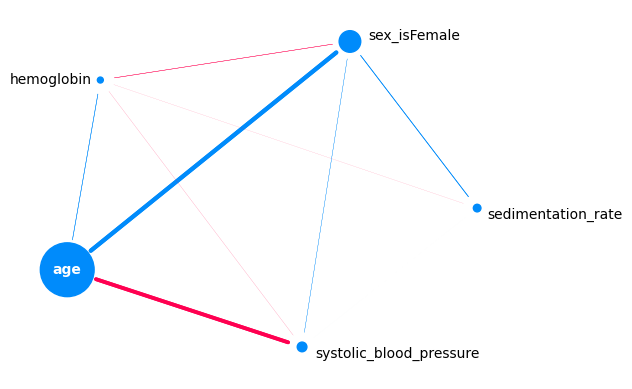

In [ ]:
print(f"Network for Males over 50 (N={subgroup_mask.sum()})")
print()

draw(
    psi=subgroup_psi_2,
    r=subgroup_r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    negative_color=negative_color,
    positive_color=positive_color,
    output_path=os.path.join('..', '..', '..','..', 'result', 'nhanesi_rf_manual_subgroup_network.jpg')
)

## Network Visualization: Rest of Cohort S₂

This network shows the aggregated SHAP influence for the rest of the cohort using the same sum-based aggregation method.

Network for Rest of Cohort (N=389)

Saving the graph to ..\..\..\..\nhanesi_rf_manual_rest_network.jpg


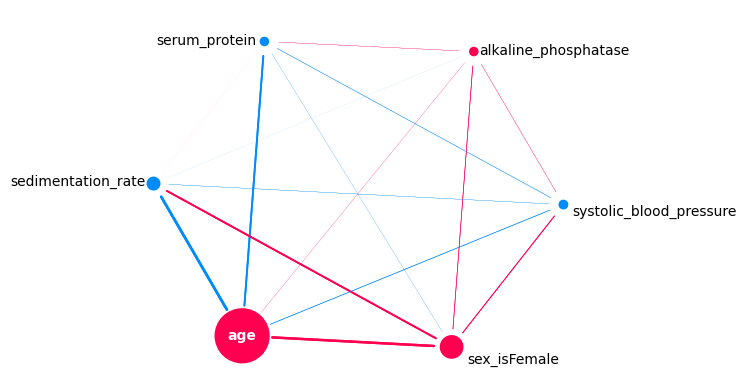

In [ ]:
print(f"Network for Rest of Cohort (N={rest_mask.sum()})")
print()

draw(
    psi=rest_psi_2,
    r=rest_r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    negative_color=negative_color,
    positive_color=positive_color,
    output_path=os.path.join('..', '..', '..','..', 'result', 'nhanesi_rf_manual_rest_network.jpg')
)